In [34]:
import pandas as pd, numpy as np, random, os, re, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

CSV_PATH = '/Users/woojin/Desktop/복분자/BukBunJa_GraduationWork-woojin/server/data/lotto_data_for_db.csv'  # 필요시 수정
assert os.path.exists(CSV_PATH), f'CSV not found: {CSV_PATH}'

In [35]:
df = pd.read_csv(CSV_PATH)

orig_cols = list(df.columns)

def find_number_columns_kor(df_):
    cols = list(df_.columns)
    # 1) 정확히 '당첨번호_1'..'당첨번호_6' 있는지
    cand = [f'당첨번호_{i}' for i in range(1,7)]
    if all(c in cols for c in cand):
        return cand
    # 2) '보너스번호'는 제외하고, '당첨번호' 패턴 정규식으로 추출
    pattern_cols = [c for c in cols if re.search(r'당첨.?번호', str(c)) and '보너' not in str(c)]
    if pattern_cols:
        # 끝 숫자 기준 정렬 후 앞 6개
        def trailing_num(name):
            m = re.search(r'(\d+)$', str(name))
            return int(m.group(1)) if m else 999
        pattern_cols.sort(key=trailing_num)
        if len(pattern_cols) >= 6:
            return pattern_cols[:6]
    # 3) 영문 패턴들(n1..n6, drwtNo1..6 등)도 시도
    lower = {str(c).lower(): c for c in cols}
    for base in ['drwtno','n','no','num','ball','col']:
        trial = []
        ok = True
        for i in range(1,7):
            key = f'{base}{i}'
            if key in lower:
                trial.append(lower[key])
            else:
                ok = False; break
        if ok:
            return trial
    # 4) 1~45 값 비율로 추정
    numlike=[]
    for c in cols:
        s = pd.to_numeric(df_[c], errors='coerce')
        if s.notna().mean() < 0.7: 
            continue
        rng = ((s>=1)&(s<=45)).mean()
        if rng > 0.7:
            numlike.append((c,rng))
    numlike.sort(key=lambda x: x[1], reverse=True)
    if len(numlike) >= 6:
        return [c for c,_ in numlike[:6]]
    raise ValueError(f"당첨번호 6개 컬럼 탐지 실패. 현재 컬럼: {orig_cols}")

num_cols = find_number_columns_kor(df)

# 숫자화 + 1..45 필터 + 정렬
nums = df[num_cols].apply(pd.to_numeric, errors='coerce').dropna()
mask = nums.applymap(lambda x: 1 <= x <= 45).all(axis=1)
nums = nums[mask]
draws = nums.apply(lambda r: sorted(map(int, r.values)), axis=1, result_type='expand')
draws.columns = ['n1','n2','n3','n4','n5','n6']
draws.head()

,n1,n2,n3,n4,n5,n6
0,3,4,12,19,22,27
1,5,13,26,29,37,40
2,2,8,13,16,23,28
3,6,17,22,28,29,32
4,14,16,23,25,31,37


In [36]:
def primes_upto(n=45):
    sieve=[True]*(n+1); sieve[0]=sieve[1]=False
    for i in range(2,int(n**0.5)+1):
        if sieve[i]:
            for j in range(i*i,n+1,i): sieve[j]=False
    return {i for i,v in enumerate(sieve) if v}
PRIMES = primes_upto(45)

def corpus_stats(df_draws):
    freq = np.zeros(46); last_seen = np.zeros(46)+9999
    for _,row in df_draws.reset_index(drop=True).iterrows():
        for x in row.values:
            x = int(x)
            freq[x]+=1; last_seen[x]=0
        last_seen[last_seen<9999]+=1
    # z-score
    freq = (freq - freq.mean())/(freq.std()+1e-6)
    last_seen = (last_seen - last_seen.mean())/(last_seen.std()+1e-6)
    return freq, last_seen

def combo_features(arr, freq, last_seen):
    arr = np.array(arr, dtype=int)
    odds = int(np.sum(arr%2==1))
    total = int(np.sum(arr))
    spread = int(arr[-1]-arr[0])
    consec = int(np.sum(np.diff(arr)==1))
    low_cnt = int(np.sum(arr<=22))
    primes = int(np.sum(np.isin(arr, list(PRIMES))))
    freq_sum = float(np.sum(freq[arr]))
    recency = float(np.sum(last_seen[arr]))
    return [odds,total,spread,consec,low_cnt,primes,freq_sum,recency]

In [37]:
freq, last_seen = corpus_stats(draws)

X_pos = [combo_features(np.sort(r.values), freq, last_seen) for _, r in draws.iterrows()]
y_pos = np.ones(len(X_pos), dtype=int)

win_set = {tuple(sorted(map(int, r.values))) for _,r in draws.iterrows()}
def rand_combo(): return tuple(sorted(random.sample(range(1,46),6)))

X_neg=[]
while len(X_neg) < len(X_pos)*10:
    c = rand_combo()
    if c in win_set: continue
    X_neg.append(combo_features(np.array(c), freq, last_seen))
y_neg = np.zeros(len(X_neg), dtype=int)

X = np.array(X_pos + X_neg, dtype=float)
y = np.concatenate([y_pos, y_neg])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = XGBClassifier(
    n_estimators=220, max_depth=5, learning_rate=0.09,
    subsample=0.9, colsample_bytree=0.8, random_state=42, eval_metric="logloss"
)
model.fit(X_train, y_train)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("검증 AUC:", round(auc,3))

검증 AUC: 0.51


In [38]:
# 사용자 가중치
weights = {
    "freq":0.6,      # 출현 빈도
    "odd_even":0.5,  # 3:3 선호
    "sum":0.5,       # 합계 100~170 선호
    "spread":0.3,    # 범위 클수록 약간 선호
    "consec":0.4,    # 연속번호 패널티
    "low_high":0.4,  # 저/고 균형(3:3)
    "recency":0.3    # 오래 안 나온 번호 선호
}

def gen_candidates(k, w, freq, last_seen):
    def weight_score(arr):
        f = combo_features(arr, freq, last_seen)
        score = 0.0
        score += w["freq"] * f[6]       # freq_sum
        score -= w["odd_even"] * abs(f[0]-3)
        # 합계 100~170 선호
        if f[1] < 100: score -= w["sum"]*(100 - f[1])/10
        if f[1] > 170: score -= w["sum"]*(f[1] - 170)/10
        score -= w["consec"] * f[3]
        score -= w["low_high"] * abs(f[4]-3)
        score += w["recency"] * f[7]
        score += w["spread"] * (f[2]/44.0)
        return score
    seen=set(); out=[]
    while len(out)<k:
        c = tuple(sorted(random.sample(range(1,46),6)))
        if c in seen: continue
        seen.add(c)
        out.append((c, weight_score(c)))
    out.sort(key=lambda x:x[1], reverse=True)
    return [c for c,_ in out]

In [45]:
random.seed(42);

K = 2000   # 후보 조합 수
TOPN = 20  # 상위 출력 개수

cand = gen_candidates(K, weights, freq, last_seen)
feats = [combo_features(np.array(c), freq, last_seen) for c in cand]
probs = model.predict_proba(np.array(feats))[:,1]
ranked = sorted(zip(cand, probs), key=lambda x:x[1], reverse=True)[:TOPN]
pick = random.choice(ranked)
c, p = pick
nums = ' '.join(map(str, c))

# ---- 번호만 출력 ----
for idx, (c, p) in enumerate(ranked, start=1):
    nums = ' '.join(map(str, c))
    print(f"후보 {idx:02}: {nums} (score={p:.6f})")
    
print(f"\n최종 추천: {nums} (score={p:.6f})")

후보 01: 15 23 29 31 33 42 (score=0.726308)
후보 02: 14 29 35 40 41 42 (score=0.479361)
후보 03: 3 4 11 13 17 19 (score=0.436681)
후보 04: 2 3 7 20 34 37 (score=0.395263)
후보 05: 20 25 33 35 38 43 (score=0.390753)
후보 06: 24 27 29 31 33 40 (score=0.379047)
후보 07: 22 29 34 39 42 45 (score=0.354485)
후보 08: 18 20 29 31 38 41 (score=0.326899)
후보 09: 10 12 18 28 34 40 (score=0.315719)
후보 10: 19 25 29 35 37 40 (score=0.314250)
후보 11: 1 8 13 14 20 22 (score=0.308200)
후보 12: 3 5 18 35 37 44 (score=0.306636)
후보 13: 5 21 22 28 40 43 (score=0.305197)
후보 14: 14 27 31 33 40 45 (score=0.304182)
후보 15: 24 26 29 30 33 38 (score=0.298186)
후보 16: 13 34 36 37 40 42 (score=0.296808)
후보 17: 10 16 25 27 29 32 (score=0.292469)
후보 18: 2 9 23 25 31 40 (score=0.287254)
후보 19: 7 18 34 40 43 45 (score=0.284398)
후보 20: 9 12 13 19 25 37 (score=0.277274)

최종 추천: 9 12 13 19 25 37 (score=0.277274)


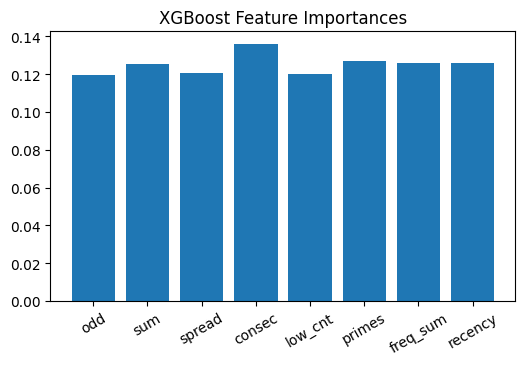

In [40]:
importances = model.feature_importances_
names = ["odd","sum","spread","consec","low_cnt","primes","freq_sum","recency"]

plt.figure(figsize=(6,3.5))
plt.bar(names, importances)
plt.xticks(rotation=30)
plt.title("XGBoost Feature Importances")
plt.show()